In [3]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [4]:
import pandas as pd
import sqlite3
df = pd.read_csv('Train.csv')
print(df.shape)
df.head()


(10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [5]:
conn = sqlite3.connect('shipping.db')
df.to_sql('shipments', conn, if_exists='replace', index=False)
pd.read_sql_query("SELECT * FROM shipments LIMIT 5;", conn)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [6]:
# Q1: Late Delivery Rate by Warehouse Block

query1 = """
SELECT
    Warehouse_block,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN "Reached.on.Time_Y.N" = 1 THEN 1 ELSE 0 END) AS late_orders,
    ROUND(SUM(CASE WHEN "Reached.on.Time_Y.N" = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS late_rate_pct
FROM shipments
GROUP BY Warehouse_block
ORDER BY late_rate_pct DESC;
"""
pd.read_sql_query(query1, conn)


,Warehouse_block,total_orders,late_orders,late_rate_pct
0,B,1833,1104,60.23
1,F,3666,2194,59.85
2,D,1834,1096,59.76
3,C,1833,1094,59.68
4,A,1833,1075,58.65


In [7]:
# Q2: Late Delivery Rate by Mode of Shipment (Flight/Ship/Road)

query2 = """
SELECT
    Mode_of_Shipment,
    COUNT(*) AS total_orders,
    ROUND(AVG("Reached.on.Time_Y.N")*100, 2) AS late_rate_pct,
    ROUND(AVG(Cost_of_the_Product), 2) AS avg_Cost
FROM shipments
GROUP BY Mode_of_Shipment
ORDER BY late_rate_pct DESC;
"""
pd.read_sql_query(query2, conn)

,Mode_of_Shipment,total_orders,late_rate_pct,avg_Cost
0,Flight,1777,60.16,209.31
1,Ship,7462,59.76,210.34
2,Road,1760,58.81,210.48


In [8]:
# Q3: Identify the Root Cause of Late Deliveries by Warehouse and Shipping Mode

query3 = """
SELECT
    Warehouse_block,
    Mode_of_Shipment,
    COUNT(*) AS total_orders,
    ROUND(AVG("Reached.on.Time_Y.N")*100,2) AS late_rate_pct
FROM shipments
GROUP BY Warehouse_block, Mode_of_Shipment
HAVING COUNT(*) > 50
ORDER BY late_rate_pct DESC
LIMIT 10;
"""
pd.read_sql_query(query3, conn)

,Warehouse_block,Mode_of_Shipment,total_orders,late_rate_pct
0,C,Flight,295,62.37
1,B,Ship,1243,60.74
2,F,Flight,592,60.14
3,F,Road,586,60.07
4,D,Flight,297,59.93
5,B,Flight,296,59.80
6,D,Ship,1245,59.76
7,F,Ship,2488,59.73
8,D,Road,292,59.59
9,C,Ship,1244,59.57


In [9]:
# Q4: Analyze the relationship between customer care calls and late delivery rates.
query4= """
SELECT
    Customer_care_calls,
    COUNT(*) AS total_orders,
    ROUND(aVG("Reached.on.Time_Y.N") * 100, 2) AS late_rate_pct,
    ROUND(AVG(Customer_rating), 2) AS avg_rating
FROM shipments
GROUP BY Customer_care_calls
ORDER BY Customer_care_Calls;
"""
pd.read_sql_query(query4, conn)

,Customer_care_calls,total_orders,late_rate_pct,avg_rating
0,2,638,65.20,3.02
1,3,3217,62.51,2.96
2,4,3557,59.77,3.00
3,5,2328,58.42,2.97
4,6,1013,51.63,3.08
5,7,246,51.63,3.00


In [10]:
# Q5: Do loyal customers receive more on-time deliveries than new customers?

query5 = """
SELECT
    CASE
        WHEN Prior_purchases <= 2 THEN 'New (0-2 orders)'
        WHEN Prior_purchases <= 5 THEN 'Regular (3-5 orders)'
        ELSE 'Loyal (6+ orders)'
    END AS customer_segment,
    COUNT(*) AS total_orders,
    ROUND(AVG("Reached.on.Time_Y.N")*100, 2) AS late_rate_pct,
    ROUND(AVG(Customer_rating), 2) AS avg_rating
FROM shipments
GROUP BY customer_segment
ORDER BY late_rate_Pct DESC;
"""
pd.read_sql_query(query5, conn)

,customer_segment,total_orders,late_rate_pct,avg_rating
0,New (0-2 orders),2599,62.52,2.96
1,Loyal (6+ orders),1003,58.92,3.03
2,Regular (3-5 orders),7397,58.77,3.00


In [11]:
# Q6: Do late deliveries significantly lower customer ratings?

query6 = """
SELECT
    CASE WHEN "Reached.on.Time_Y.N" = 1 THEN 'Late' ELSE 'On Time' END AS delivery_status,
    COUNT(*) AS total_orders,
    ROUND(AVG(Customer_rating), 2) AS avg_rating,
    MIN(Customer_rating) AS min_rating,
    MAX(Customer_rating) AS max_rating
FROM shipments
GROUP BY delivery_status;
"""
pd.read_sql_query(query6, conn)

,delivery_status,total_orders,avg_rating,min_rating,max_rating
0,Late,6563,3.01,1,5
1,On Time,4436,2.97,1,5


In [12]:
# Q7: Does a higher discount indicate a higher risk of late delivery?

query7 = """

SELECT
    CASE
      WHEN Discount_offered <= 10 THEN '0-10%'
      WHEN Discount_offered <= 30 THEN '11-30%'
      WHEN Discount_offered <= 50 THEN '31-50%'
      ELSE '50%+'
    END AS discount_bracket,
    COUNT (*) AS total_orders,
    ROUND(AVG("Reached.on.Time_Y.N")*100, 2) AS late_rate_pct,
    ROUND(AVG(Cost_of_the_Product), 2) AS avg_cost
FROM shipments
GROUP BY discount_bracket
ORDER BY late_rate_pct DESC;
"""
pd.read_sql_query(query7, conn)

,discount_bracket,total_orders,late_rate_pct,avg_cost
0,50%+,733,100.00,196.93
1,31-50%,977,100.00,197.01
2,11-30%,937,100.00,194.77
3,0-10%,8352,46.89,214.63


In [13]:
# Q8: Are high-importance products delivered on time more often than low-importance products?

query8= """
SELECT
    Product_importance,
    COUNT(*) AS total_orders,
    ROUND(AVG("Reached.on.Time_Y.N") * 100, 2) AS late_rate_pct,
    ROUND(AVG(Weight_in_gms), 0) AS avg_weight
FROM shipments
GROUP BY Product_importance
ORDER BY
    CASE Product_importance
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'low' THEN 3
    END;
"""
pd.read_sql_query(query8, conn)

,Product_importance,total_orders,late_rate_pct,avg_weight
0,high,948,64.98,4006.0
1,medium,4754,59.05,3712.0
2,low,5297,59.28,3497.0


In [14]:
# Q9: How does product weight affect late delivery?

query9 = """
SELECT
    CASE
        WHEN Weight_in_gms < 2000 THEN 'Light (<2kg)'
        WHEN Weight_in_gms < 4000 THEN 'Medium (2-4kg)'
        ELSE 'Heavy (4kg+)'
    END AS weight_category,
    COUNT(*) AS total_orders,
    ROUND(aVG("Reached.on.Time_Y.N") * 100, 2) AS late_rate_pct
FROM shipments
GROUP BY weight_category
ORDER BY late_rate_pct DESC;
"""
pd.read_sql_query(query9, conn)

,weight_category,total_orders,late_rate_pct
0,Medium (2-4kg),1790,99.89
1,Light (<2kg),3241,67.79
2,Heavy (4kg+),5968,43.20


In [15]:

# Q10: Rank warehouses by late delivery using a window function.

query10 = """
WITH warehouse_stats AS (
    SELECT
          Warehouse_block,
          COUNT(*) AS total_orders,
          ROUND(AVG("Reached.on.TIME_Y.N") * 100, 2) AS late_rate_pct
     FROM shipments
     GROUP BY Warehouse_block
)
SELECT
          Warehouse_block,
          total_orders,
          late_rate_pct,
          RANK() OVER (ORDER BY late_rate_pct DESC) AS late_rank
FROM warehouse_stats;
     """
pd.read_sql_query(query10, conn)



,Warehouse_block,total_orders,late_rate_pct,late_rank
0,B,1833,60.23,1
1,F,3666,59.85,2
2,D,1834,59.76,3
3,C,1833,59.68,4
4,A,1833,58.65,5


In [16]:
# Q11: Compare the late delivery rate of each gender with the overall late delivery rate.
query11 = """
SELECT
    Gender,
    COUNT(*) AS total_orders,
    ROUND(aVG("Reached.on.Time_Y.N") * 100, 2) AS late_rate_pct,
    ROUND((SELECT AVG("Reached.on.Time_Y.N") * 100 FROM shipments),2) AS overall_avg_late_pct
FROM shipments
GROUP BY Gender;
"""
pd.read_sql_query(query11, conn)




,Gender,total_orders,late_rate_pct,overall_avg_late_pct
0,F,5545,59.44,59.67
1,M,5454,59.90,59.67


In [17]:
#  Q12: Identify the top multi-factor delivery risk profiles.
query12 = """
SELECT
    Mode_of_Shipment,
    Product_importance,
    CASE
        WHEN Discount_offered > 30 THEN 'High Discount'
        ELSE 'Normal Discount'
    END AS discount_flag,
    COUNT(*) AS total_orders,
    ROUND(AVG("Reached.on.Time_Y.N") * 100,2) AS late_rate_pct
FROM shipments
GROUP BY Mode_of_Shipment, Product_importance, discount_flag
HAVING COUNT(*) > 30
ORDER BY late_rate_pct DESC
LIMIT 10;
"""
pd.read_sql_query(query12, conn)



,Mode_of_Shipment,Product_importance,discount_flag,total_orders,late_rate_pct
0,Flight,low,High Discount,118,100.00
1,Flight,medium,High Discount,117,100.00
2,Road,low,High Discount,130,100.00
3,Road,medium,High Discount,120,100.00
4,Ship,high,High Discount,122,100.00
5,Ship,low,High Discount,537,100.00
6,Ship,medium,High Discount,516,100.00
7,Road,high,Normal Discount,134,58.96
8,Ship,high,Normal Discount,505,58.61
9,Flight,medium,Normal Discount,659,53.87


In [18]:
from scipy.stats import chi2_contingency
import numpy as np

In [19]:
def run_chi_square(df, column, target='Reached.on.Time_Y.N'):
    """
    Run a chi-square test of independence between a categorical variable
    and the delivery status target.
    Returns the chi2 statistic and p-value.
    """
    contingency_table = pd.crosstab(df[column], df[target])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    conclusion = "Statistically significant (associated with late delivery)" if p_value < 0.05 else "NOT statistically significant"
    print(f"--- {column} ---")
    print(f"Chi2 statictic: {chi2:.2f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Conclusion: {conclusion}")
    print()

    return chi2, p_value


In [20]:
# Test categorical variables against delivery status
varibles_to_test = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

results = {}
for var in varibles_to_test:
    chi2, p_val = run_chi_square(df, var)
    results[var] = {'chi2': chi2, 'p_value': p_val}

--- Warehouse_block ---
Chi2 statictic: 1.09
P-value: 0.895952
Conclusion: NOT statistically significant

--- Mode_of_Shipment ---
Chi2 statictic: 0.74
P-value: 0.689549
Conclusion: NOT statistically significant

--- Product_importance ---
Chi2 statictic: 12.21
P-value: 0.002230
Conclusion: Statistically significant (associated with late delivery)

--- Gender ---
Chi2 statictic: 0.22
P-value: 0.636703
Conclusion: NOT statistically significant



In [21]:
# Bin Discount_offered into brackets, consistent with the SQL query above
df['discount_bracket'] = pd.cut(
    df['Discount_offered'],
    bins=[-1, 10, 30, 50, 100],
    labels=['0-10%', '11-30%', '31-50%', '50%+']
)
chi2_discount, p_discount = run_chi_square(df, 'discount_bracket')
results['discount_bracket'] = {'chi2': chi2_discount, 'p_value': p_discount}


--- discount_bracket ---
Chi2 statictic: 2356.17
P-value: 0.000000
Conclusion: Statistically significant (associated with late delivery)



In [40]:
summary_df = pd.DataFrame(results).T
summary_df = summary_df.sort_values('chi2', ascending=False)
summary_df.columns = ['chi2_statistic', 'p_value']
summary_df

,chi2_statistic,p_value
discount_bracket,2356.165491,0.000000
Product_importance,12.211164,0.002230
Warehouse_block,1.089387,0.895952
Mode_of_Shipment,0.743436,0.689549
Gender,0.223080,0.636703


In [34]:
# Check whether any order with discount > 10% was still delivered on time
exception_check = df[(df['Discount_offered'] > 10) & (df['Reached.on.Time_Y.N'] == 0)]
print(f"Orders with discount > 10% but delivered ON TIME: {len(exception_check)}")
print(f"Total orders with discount > 10%: {len(df[df['Discount_offered'] > 10])}")

Orders with discount > 10% but delivered ON TIME: 0
Total orders with discount > 10%: 2647


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df_model = df.copy()

# Encode categoryical columns into numeric
le = LabelEncoder()
categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
df_model.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,discount_bracket
0,1,3,0,4,2,177,3,1,0,44,1233,1,31-50%
1,2,4,0,4,5,216,2,1,1,59,3088,1,50%+
2,3,0,0,2,2,183,4,1,1,48,3374,1,31-50%
3,4,1,0,3,3,176,4,2,1,10,1177,1,0-10%
4,5,2,0,2,2,184,3,2,0,46,2484,1,31-50%


In [51]:
target = 'Reached.on.Time_Y.N'

# Model A: includes Discount_offered(has leakage)
features_A = ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
              'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
              'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']
# Model B: excludes Discount_offered (no leakage, realistic)
features_B = ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
              'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
              'Product_importance', 'Gender', 'Weight_in_gms']

In [53]:
def train_and_evaluate(df, features, target, model_name):
    """
    Train a logistic regression model on the given features and print evaluation metrics.
    """
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print(f"=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    return model, acc, y_test, y_pred



In [54]:
model_A, acc_A, y_test_A, y_pred_A  = train_and_evaluate(
    df_model, features_A, target, "Model A (with Discount_offred - has leakage)")
model_B, acc_B, y_test_B, y_pred_B = train_and_evaluate(
    df_model, features_B, target, "Model B (without Discount_offred - realistic)")



=== Model A (with Discount_offred - has leakage) ===
Accuracy: 0.6355
              precision    recall  f1-score   support

           0       0.55      0.55      0.55       895
           1       0.69      0.69      0.69      1305

    accuracy                           0.64      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.64      0.64      0.64      2200

=== Model B (without Discount_offred - realistic) ===
Accuracy: 0.6314
              precision    recall  f1-score   support

           0       0.57      0.41      0.47       895
           1       0.66      0.79      0.72      1305

    accuracy                           0.63      2200
   macro avg       0.61      0.60      0.59      2200
weighted avg       0.62      0.63      0.62      2200



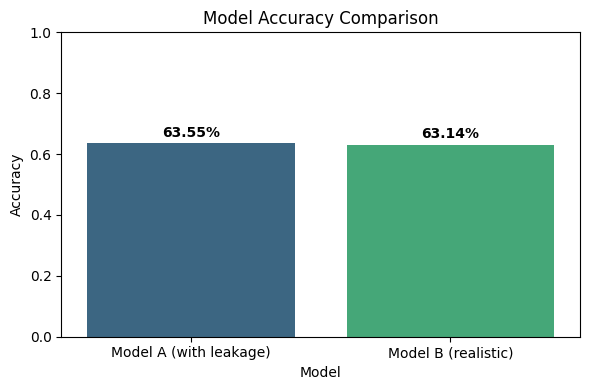

In [55]:
comparison = pd.DataFrame({
    'Model': ['Model A (with leakage)', 'Model B (realistic)'],
    'Accuracy': [acc_A, acc_B]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=comparison, x='Model', y='Accuracy', hue='Model', palette='viridis', legend=False)
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(comparison['Accuracy']):
  plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()




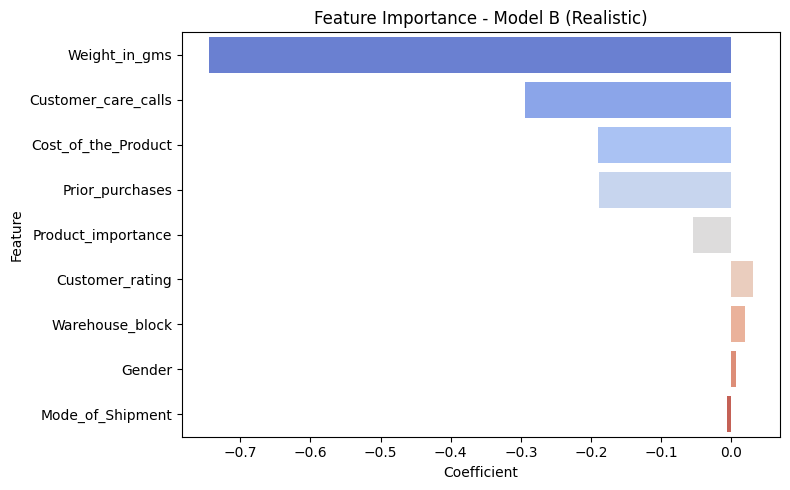

,Feature,Coefficient
8,Weight_in_gms,-0.744087
2,Customer_care_calls,-0.294415
4,Cost_of_the_Product,-0.190438
5,Prior_purchases,-0.188857
6,Product_importance,-0.054375
3,Customer_rating,0.030405
0,Warehouse_block,0.018593
7,Gender,0.006259
1,Mode_of_Shipment,-0.005759


In [56]:
feature_importance = pd.DataFrame({
    'Feature': features_B,
    'Coefficient': model_B.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Feature Importance - Model B (Realistic)')
plt.tight_layout()
plt.show()

feature_importance

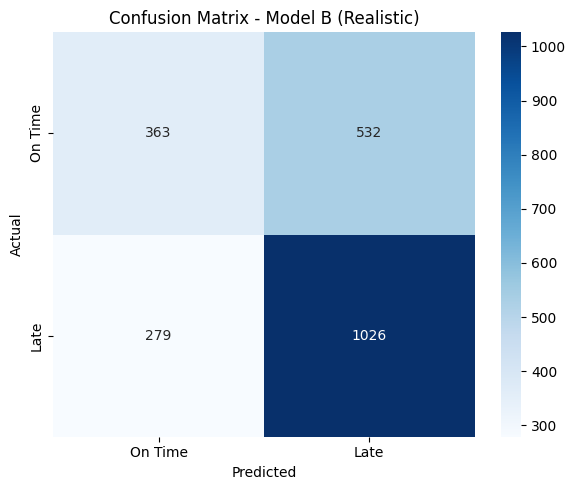

In [58]:
## Confusion Matrix for Model B (realistic model)
cm = confusion_matrix(y_test_B, y_pred_B)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
plt.title('Confusion Matrix - Model B (Realistic)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [60]:
## Export the cleaned dataset for Tableau
# Add readable labels instead of encoded numbers, for better Tableau visuals
df_tableau = df.copy()
df_tableau['Delivery_Status'] = df_tableau['Reached.on.Time_Y.N'].map({0: 'On Time', 1: 'Late'})
df_tableau.to_csv('shipping_data_for_tableau.csv', index=False)
from google.colab import files
files.download('shipping_data_for_tableau.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>